In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
import json
import re
import matplotlib.pyplot as plt

In [2]:
plot_metrics = ['hellaswag', 'lambada_openai', 'lambada_standard', 'piqa', 'truthfulqa_mc2', 'winogrande', 'arc_challenge', 'gsm8k', 'medmcqa', 'mmlu', 'paloma_wikitext_103', ]

metric_keys = [
    'acc_norm,none',
    'acc,none',
    'exact_match,strict-match',
    'exact_match,flexible-extract',
    'perplexity,none',
    'word_perplexity,none'
]

def extract_number_from_filename(filename):
    """Extract the number from filename like 'lm_eval_begin_0.json' or 'lm_eval_interval_1221.json'"""
    # Remove .json extension and split by underscore
    name_without_ext = filename.replace('.json', '')
    parts = name_without_ext.split('_')
    # The number is always the last part
    return int(parts[-1].replace('step', ''))

In [7]:
res_path = "./results/midtrain_allenai"
output_csv = './results_data.csv'
output_dir = "./figures"
os.makedirs(output_dir, exist_ok=True)

In [8]:
res_folders = os.listdir(res_path)
result_list = []
for res_folder in res_folders:
    disp_setting = re.search(r'disp-([^-]+-[^-]+)', res_folder).group(1)
    files = sorted([f for f in os.listdir(os.path.join(res_path, res_folder)) if f.startswith('lm_eval_')])
    print(f"{res_folder}")
    for file in files:
        print(f"{file}")
        step = extract_number_from_filename(file)
        with open(f'{res_path}/{res_folder}/{file}', 'r') as f:
            data = json.load(f)

        result = {}

        result['filename'] = file
        result['step'] = step
        result['disp'] = disp_setting
        
        for plot_metric in plot_metrics:
            res = data['results'][plot_metric]
            key_used = None
            for key in metric_keys:
                if key in res.keys():
                    key_used = key
                    break
            assert key_used is not None, 'no key found'
            result_value = res[key_used]
            result_key = plot_metric + ',' + key_used
            result[result_key] = result_value

        result_list.append(result)

df = pd.DataFrame(result_list).sort_values('step')
df.to_csv(output_csv, index=False)


OLMo-2-0425-1B_DKYoon-SlimPajama-6B_lr-1e-06_token-1600000000_disp-covariance-0.5-all_fewshot-1_maxsample-200_seed-1
lm_eval_begin_0.json
lm_eval_interval_10989.json
lm_eval_interval_1221.json
lm_eval_interval_2442.json
lm_eval_interval_3663.json
lm_eval_interval_4884.json
lm_eval_interval_6105.json
lm_eval_interval_7326.json
lm_eval_interval_8547.json
lm_eval_interval_9768.json
OLMo-2-0425-1B_DKYoon-SlimPajama-6B_lr-1e-06_token-1600000000_disp-infonce_l2-0.5-all_fewshot-1_maxsample-200_seed-1
lm_eval_begin_0.json
lm_eval_interval_10989.json
lm_eval_interval_1221.json
lm_eval_interval_2442.json
lm_eval_interval_3663.json
lm_eval_interval_4884.json
lm_eval_interval_6105.json
lm_eval_interval_7326.json
lm_eval_interval_8547.json
lm_eval_interval_9768.json
OLMo-2-0425-1B_DKYoon-SlimPajama-6B_lr-1e-06_token-1600000000_disp-hinge-0.5-all_fewshot-1_maxsample-200_seed-1
lm_eval_begin_0.json
lm_eval_interval_10989.json
lm_eval_interval_1221.json
lm_eval_interval_2442.json
lm_eval_interval_3663

In [9]:
df

,filename,step,disp,"hellaswag,acc_norm,none","lambada_openai,acc,none","lambada_standard,acc,none","piqa,acc_norm,none","truthfulqa_mc2,acc,none","winogrande,acc,none","arc_challenge,acc_norm,none","gsm8k,exact_match,strict-match","medmcqa,acc_norm,none","mmlu,acc,none","paloma_wikitext_103,word_perplexity,none"
0,lm_eval_begin_0.json,0,covariance-0.5,0.630,0.660,0.575,0.770,0.388765,0.700,0.410,0.305,0.285,0.426440,12.855828
10,lm_eval_begin_0.json,0,infonce_l2-0.5,0.630,0.660,0.575,0.770,0.388765,0.700,0.410,0.305,0.285,0.426440,12.855828
30,lm_eval_begin_0.json,0,infonce_cosine-0.5,0.630,0.660,0.575,0.770,0.388765,0.700,0.410,0.305,0.285,0.426440,12.855828
20,lm_eval_begin_0.json,0,hinge-0.5,0.630,0.660,0.575,0.770,0.388765,0.700,0.410,0.305,0.285,0.426440,12.855828
40,lm_eval_begin_0.json,0,None-1,0.630,0.660,0.575,0.770,0.388765,0.700,0.410,0.305,0.285,0.426440,12.855828
12,lm_eval_interval_1221.json,1221,infonce_l2-0.5,0.635,0.630,0.555,0.775,0.406149,0.670,0.400,0.215,0.320,0.424153,13.116436
2,lm_eval_interval_1221.json,1221,covariance-0.5,0.630,0.640,0.565,0.780,0.403989,0.695,0.385,0.230,0.305,0.428074,12.846022
22,lm_eval_interval_1221.json,1221,hinge-0.5,0.625,0.635,0.555,0.780,0.404037,0.715,0.395,0.270,0.305,0.425787,12.834874
32,lm_eval_interval_1221.json,1221,infonce_cosine-0.5,0.635,0.635,0.560,0.775,0.403720,0.700,0.390,0.235,0.310,0.427311,12.825515
43,lm_eval_interval_1221.json,1221,None-1,0.630,0.640,0.560,0.775,0.403220,0.705,0.400,0.270,0.300,0.428291,12.847210


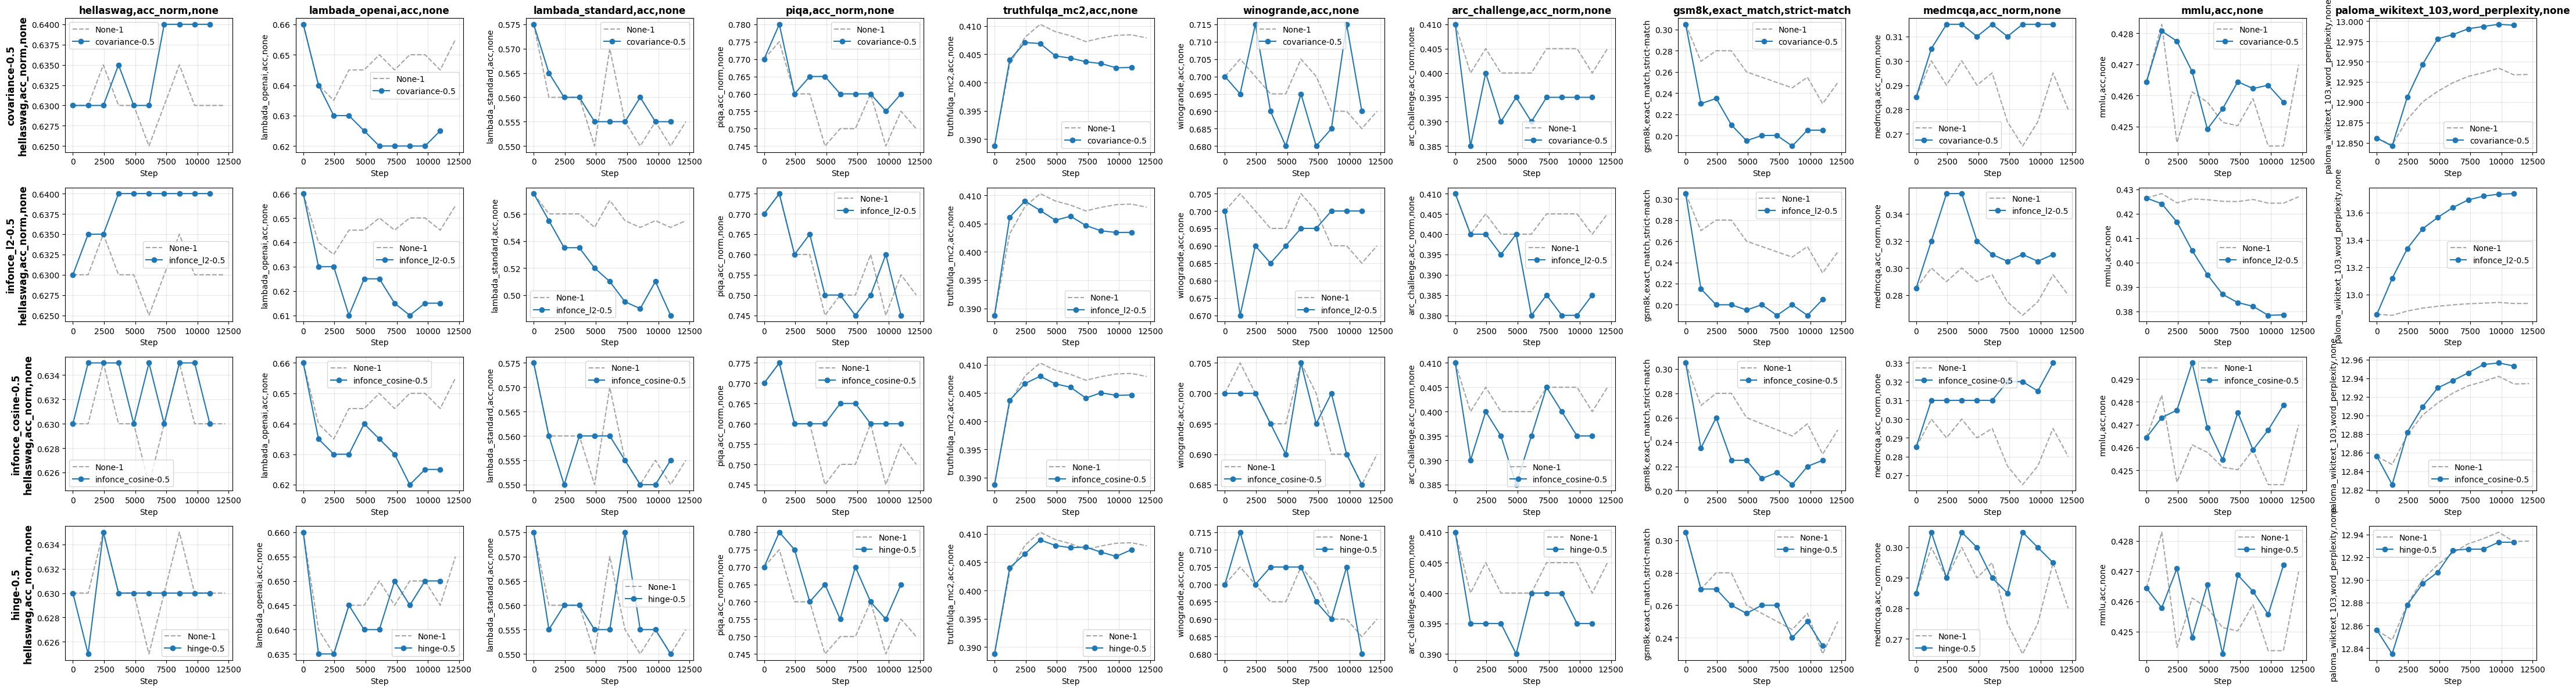

In [10]:
# Get unique dispersion methods (excluding None-1)
disp_methods = [d for d in df['disp'].unique() if d != 'None-1']
# Get metric columns (excluding filename, step, disp)
metric_cols = [col for col in df.columns if col not in ['filename', 'step', 'disp']]

# Create subplots
fig, axes = plt.subplots(len(disp_methods), len(metric_cols), 
                        figsize=(4*len(metric_cols), 3*len(disp_methods)))

# Ensure axes is 2D array
if len(disp_methods) == 1:
    axes = axes.reshape(1, -1)
if len(metric_cols) == 1:
    axes = axes.reshape(-1, 1)

# Get baseline data (None-1)
baseline_data = df[df['disp'] == 'None-1']

# Plot for each dispersion method and metric
for i, disp in enumerate(disp_methods):
    for j, metric in enumerate(metric_cols):
        ax = axes[i, j]
        
        # Plot baseline (None-1) as gray dashed line
        if not baseline_data.empty:
            ax.plot(baseline_data['step'], baseline_data[metric], 
                   color='gray', linestyle='--', alpha=0.7, label='None-1')
        
        # Plot current dispersion method
        method_data = df[df['disp'] == disp]
        if not method_data.empty:
            ax.plot(method_data['step'], method_data[metric], 
                   marker='o', label=disp)
        
        # Set labels and title
        ax.set_xlabel('Step')
        ax.set_ylabel(metric)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add column labels on top row
        if i == 0:
            ax.set_title(metric, fontsize=12, fontweight='bold')
    
    # Add row labels on left column
    if len(metric_cols) > 0:
        axes[i, 0].set_ylabel(f'{disp}\n{metric_cols[0]}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df[df['step'] == 0]#[['arc_challenge,acc_norm,none']]

,filename,step,disp,"hellaswag,acc_norm,none","lambada_openai,acc,none","lambada_standard,acc,none","piqa,acc_norm,none","truthfulqa_mc2,acc,none","winogrande,acc,none","arc_challenge,acc_norm,none","gsm8k,exact_match,strict-match","medmcqa,acc_norm,none","mmlu,acc,none","paloma_wikitext_103,word_perplexity,none"
0,lm_eval_eval_ckpt_begin_step0.json,0,None-1,0.58,0.62,0.565,0.74,0.391939,0.575,0.365,0.025,0.395,0.326037,12.631878
2,lm_eval_eval_ckpt_begin_step0.json,0,infonce_cosine-0.5,0.58,0.62,0.565,0.74,0.391939,0.575,0.365,0.025,0.395,0.326037,12.631878
6,lm_eval_eval_ckpt_begin_step0.json,0,hinge-0.5,0.58,0.62,0.565,0.74,0.391939,0.575,0.365,0.025,0.395,0.326037,12.631878
4,lm_eval_eval_ckpt_begin_step0.json,0,covariance-0.5,0.58,0.62,0.565,0.74,0.391939,0.575,0.365,0.025,0.395,0.326037,12.631878
8,lm_eval_eval_ckpt_begin_step0.json,0,infonce_l2-0.5,0.58,0.62,0.565,0.74,0.391939,0.575,0.325,0.035,0.310,0.326255,12.631878


In [ ]:
step_col = 'step'
to_plot_cols = [f for f in df.columns if f not in ['filename', 'step']]
methods = 

SyntaxError: invalid syntax (3850489603.py, line 3)

['hellaswag,acc_norm,none',
 'lambada_openai,acc,none',
 'lambada_standard,acc,none',
 'piqa,acc_norm,none',
 'truthfulqa_mc2,acc,none',
 'winogrande,acc,none',
 'arc_challenge,acc_norm,none',
 'gsm8k,exact_match,strict-match',
 'medmcqa,acc_norm,none',
 'mmlu,acc,none',
 'paloma_wikitext_103,word_perplexity,none']

In [ ]:
data

{'results': {'hellaswag': {'alias': 'hellaswag',
   'acc,none': 0.475,
   'acc_stderr,none': 0.0353997274497642,
   'acc_norm,none': 0.565,
   'acc_norm_stderr,none': 0.03514328173714407},
  'lambada_openai': {'alias': 'lambada_openai',
   'perplexity,none': 5.613191204849795,
   'perplexity_stderr,none': 0.7023954075033207,
   'acc,none': 0.625,
   'acc_stderr,none': 0.03431856376795913},
  'lambada_standard': {'alias': 'lambada_standard',
   'perplexity,none': 7.622786948217177,
   'perplexity_stderr,none': 1.031526615817041,
   'acc,none': 0.555,
   'acc_stderr,none': 0.0352289710609046},
  'paloma_wikitext_103': {'alias': 'Wikitext-103',
   'word_perplexity,none': 12.827861271186743,
   'word_perplexity_stderr,none': 'N/A',
   'byte_perplexity,none': 1.6110388714562571,
   'byte_perplexity_stderr,none': 'N/A',
   'bits_per_byte,none': 0.687991304088317,
   'bits_per_byte_stderr,none': 'N/A'},
  'piqa': {'alias': 'piqa',
   'acc,none': 0.74,
   'acc_stderr,none': 0.03109395714370027